# Synthetic bistable RNA — single-population fit

Interactive version of `fits_paper/designed_sequence/scripts/run_synthetic_bistable.py`,
restricted to **one** value of `POP1` so the resulting `MultiSystemsFit` instance
(`multi_sys`) stays alive in the kernel afterwards for exploration.

Like the script, this still writes a real output directory to disk (`summary.log`,
`params1D.txt`, `detailed/`, `plots/…`) — `MultiSystemsFit` saves `params1D.txt` on every
optimizer callback regardless of `do_plots`, so a real fit always needs a real
`output_dir`. To avoid clobbering the paper's actual results in
`fits_paper/designed_sequence/outputs/synthetic_bistable_main/`, this notebook writes to
its own `synthetic_bistable_notebook/` folder instead.

In [1]:
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.environ.setdefault("RNA_STRUCT_HOME", repo_root)
sys.path.insert(0, repo_root)
os.chdir(repo_root)  # so relative paths below (fits_paper/...) resolve like the script does


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from merge_rna import Experiment, create_exp_synthetic_comb, MultiSystemsFit


## Configuration

Change `POP1` to explore a different population mixture (paper used `[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]`).

In [3]:
POP1 = 0.8  # fraction of population 1 (conformation 1)

OUTPUT_DIR = os.path.join('fits_paper', 'designed_sequence', 'outputs', 'synthetic_bistable_notebook')
REF_PARAMS_PATH = os.path.join('fits_paper', 'designed_sequence', 'synthetic', 'reference_physical_params.txt')


## Build a reference `params_dict`

Same bootstrap as `run_synthetic_bistable.py`: load the reference physical params and use a real 0 mM Redmond experiment purely to get a `System` (via `pack_params`) that knows how to unpack the 1D parameter vector. `skip_output_setup=True` is safe here because we never call `.fit()` on `_multi_ref` — no output directory is ever touched.

In [4]:
_params_1D_ref = np.loadtxt(REF_PARAMS_PATH)

_exp_ref_0mM = next(
    (Experiment(p) for p in Experiment.paths_to_redmond_ivt_data_txt if Experiment(p).conc_mM == 0),
    None)
if _exp_ref_0mM is None:
    raise RuntimeError("Could not find a 0 mM Redmond experiment to build reference params_dict")

_multi_ref = MultiSystemsFit([_exp_ref_0mM], validation_exps=None, infer_1D_sc=False, skip_output_setup=True)
params_dict_ref = _multi_ref.pack_params(_params_1D_ref, _multi_ref.systems[0])


## Build the synthetic experiment for `POP1`

In [5]:
exp = create_exp_synthetic_comb(pop1=POP1, same_system=False, params_dict=params_dict_ref)

print(f"Sequence length: {exp.N_seq}")
print(f"Temperature: {exp.temp_C}°C")
print(f"System name: {exp.system_name}")


Sequence length: 148
Temperature: 37°C
System name: bistable_synthetic_80


## Construct the fit object

Same arguments as the script, plus `overwrite=True` — reruns of this cell archive the previous attempt into `OUTPUT_DIR/_archive/` instead of blocking on an `input()` prompt.

In [ ]:
multi_sys = MultiSystemsFit(
    experiments=[exp],
    output_suffix=f'synthetic_bistable_{POP1*100:.0f}',
    root_dir=OUTPUT_DIR,
    infer_1D_sc=True,
    fit_mode='sequential',
    do_plots=True,
    print_to_std_out=True,
    reg_weight=0.,  # weight of KL regularization
    overwrite=True,
)


## Run the fit

`result` is the final `scipy.optimize.OptimizeResult`, but `multi_sys` itself is what we keep around to explore below.

In [ ]:
result = multi_sys.fit()
print(f"\nConverged: {result.success}  |  final loss: {result.fun:.4f}  |  message: {result.message}")


## Explore `multi_sys`

Everything below reads from the live `MultiSystemsFit` object in memory — no need to
reload anything from disk. Useful attributes:

- `multi_sys.systems` — list of `System` objects (one per distinct system name)
- `multi_sys.fit_result` — final `OptimizeResult` (`.x`, `.fun`, `.success`)
- `multi_sys.pack_params(params_1d, system)` — unpack a 1D param vector into a labeled dict
- `multi_sys.losses_exp_fit` / `multi_sys.kl_losses_exp_fit` — per-experiment NLL / KL loss
- `multi_sys.params_history` — per-iteration trajectories of `mu_r`, `p_b`, `p_bind`, `m0`, `m1`
- `multi_sys.output_dir` / `multi_sys.output_paths` — where this run's files were written

Note: `multi_sys.get_result()` is broken (imports a module that doesn't exist in this repo)
— use `pack_params` directly instead, as done below.

In [ ]:
system = multi_sys.systems[0]
print(f"system: {system.sys_name}")
print(f"N_seq: {system.N_seq}")
print(f"experiments in system: {[e.ID for e in system.exp_fits_all]}")


In [ ]:
params = multi_sys.pack_params(multi_sys.fit_result.x, system)
params


### Fitted profiles

In [ ]:
system.plot_pairing_probs(**params)
plt.show()


In [ ]:
system.plot_mut_profiles(**params)
plt.show()


In [ ]:
system.plot_lambdas(params['lambda_sc'])
plt.show()


### Optimization diagnostics

In [ ]:
multi_sys.plot_loss()
plt.show()


In [ ]:
multi_sys.plot_params()
plt.show()


In [ ]:
print("NLL loss per experiment:", multi_sys.losses_exp_fit)
print("KL loss per experiment:  ", multi_sys.kl_losses_exp_fit)


### What got written to disk

`params1D.txt`/logs are saved on every optimizer callback, plots on the first/last (and periodic) callbacks — this happens even though we're exploring everything from the live object above.

In [ ]:
print(f"output_dir: {multi_sys.output_dir}\n")
for label, path in multi_sys.output_paths.items():
    print(f"[{label}] {path}")
    for f in sorted(os.listdir(path)):
        print(f"    {f}")


### What I want to check

In [ ]:
exp_index = 0

In [ ]:
physical_params = params.copy()
physical_params.pop("lambda_sc")
physical_params

In [ ]:
experiment_fitted = system.exp_fits_all[exp_index]

In [ ]:
mu_r = physical_params["mu_r"]
mu_j = mu_r + system.kBT * np.log((experiment_fitted.conc_mM +.1)/1000) if experiment_fitted.conc_mM is not None else mu_r
p_b = physical_params["p_b"]
p_bind = physical_params["p_bind"]

In [ ]:
m0 = physical_params["m0"]
m1 = physical_params["m1"]
eps_b = system.eps_b

In [ ]:
p_chem_bind_no_pairing = experiment_fitted.compute_p_cb(mu_j, p_b, p_bind, np.zeros(experiment_fitted.N_seq))
p_chem_bind_with_pairing = experiment_fitted.compute_p_cb(mu_j, p_b, p_bind, np.ones(experiment_fitted.N_seq))
p_mut_no_pairing = experiment_fitted.compute_mutation_profile(m0, m1, eps_b, p_chem_bind_no_pairing)
p_mut_with_pairing = experiment_fitted.compute_mutation_profile(m0, m1, eps_b, p_chem_bind_with_pairing)
a_from_merge = p_mut_no_pairing
b_from_merge = p_mut_with_pairing- p_mut_no_pairing

In [ ]:
experiment_fitted.use_interpolated_ps

In [ ]:
pp_meregrna = experiment_fitted.get_ps(experiment_fitted.compute_penalty_m(mu_j, p_b), params['lambda_sc'], interpolated=experiment_fitted.use_interpolated_ps)

In [ ]:
system.plot_mut_profiles(**params)
plt.show()

In [ ]:
plt.plot(a_from_merge+b_from_merge*pp_meregrna)
plt.show()

In [ ]:
plt.plot(pp_meregrna)
plt.show()

## Try to run secod phase fit starting from maxent fit

In [6]:
OUTPUT_DIR_2 = os.path.join('fits_paper', 'designed_sequence', 'outputs', 'synthetic_bistable_notebook_init_guess')

In [7]:
init_guess_path = "/home/mauro-maglione/Documents/MERGE-RNA/my_merge_rna/params1D_maxent.txt"

In [8]:
#before running check that the experiment is the same as the one used to generate the init_guess_path
multi_sys_init_guess = MultiSystemsFit(
    experiments=[exp],
    output_suffix=f'synthetic_bistable_{POP1*100:.0f}',
    root_dir=OUTPUT_DIR_2,
    infer_1D_sc=True,
    fit_mode='lambda_only',   # phase 2 only
    guess=init_guess_path,    # full vector: physical params + lambda_sc
    do_plots=True,
    print_to_std_out=True,
    reg_weight=0.0,
)

fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[WARNING] no 0 conc experiment found. eps_b will be set to zeros.


Starting fitting process of bistable_synthetic_80, 2026-07-10 10:53:25.576822
fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[INFO] Initial guess:
[ 0.4045605   0.14104733  0.36251399  0.23412978  0.06800555  0.00203605
  0.00106579  0.68525348  1.          0.75848681  0.84697163  1.
  0.84535945  0.65552553  1.          0.33618927  0.61960713  1.
  0.6026022   0.57190887  0.67742485  1.          0.63792697  1.
  0.43556548  1.         -1.         -1.          0.10516973 -0.4493681
  1.          1.          0.55828578  1.         -1.          0.03413718
  0.33423892  0.54298124  0.50863383  0.54554637  1.         -0.3226056
 -0.6305747   1.          0.38319741 -1.          0.29066992  0.50396558
  0.50497962  0.42247718  0.18289372  0.23807314 -1.         -1.
  0.24010279  0.19174445  0.19337336  0.26760752 -1.          0.26758105
  0.19243825  0.2304925   0.29010206  0.28909417  0.38138518 -1.
  0.353

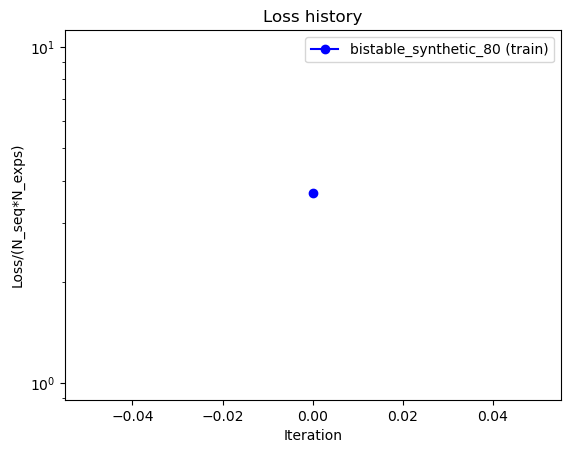

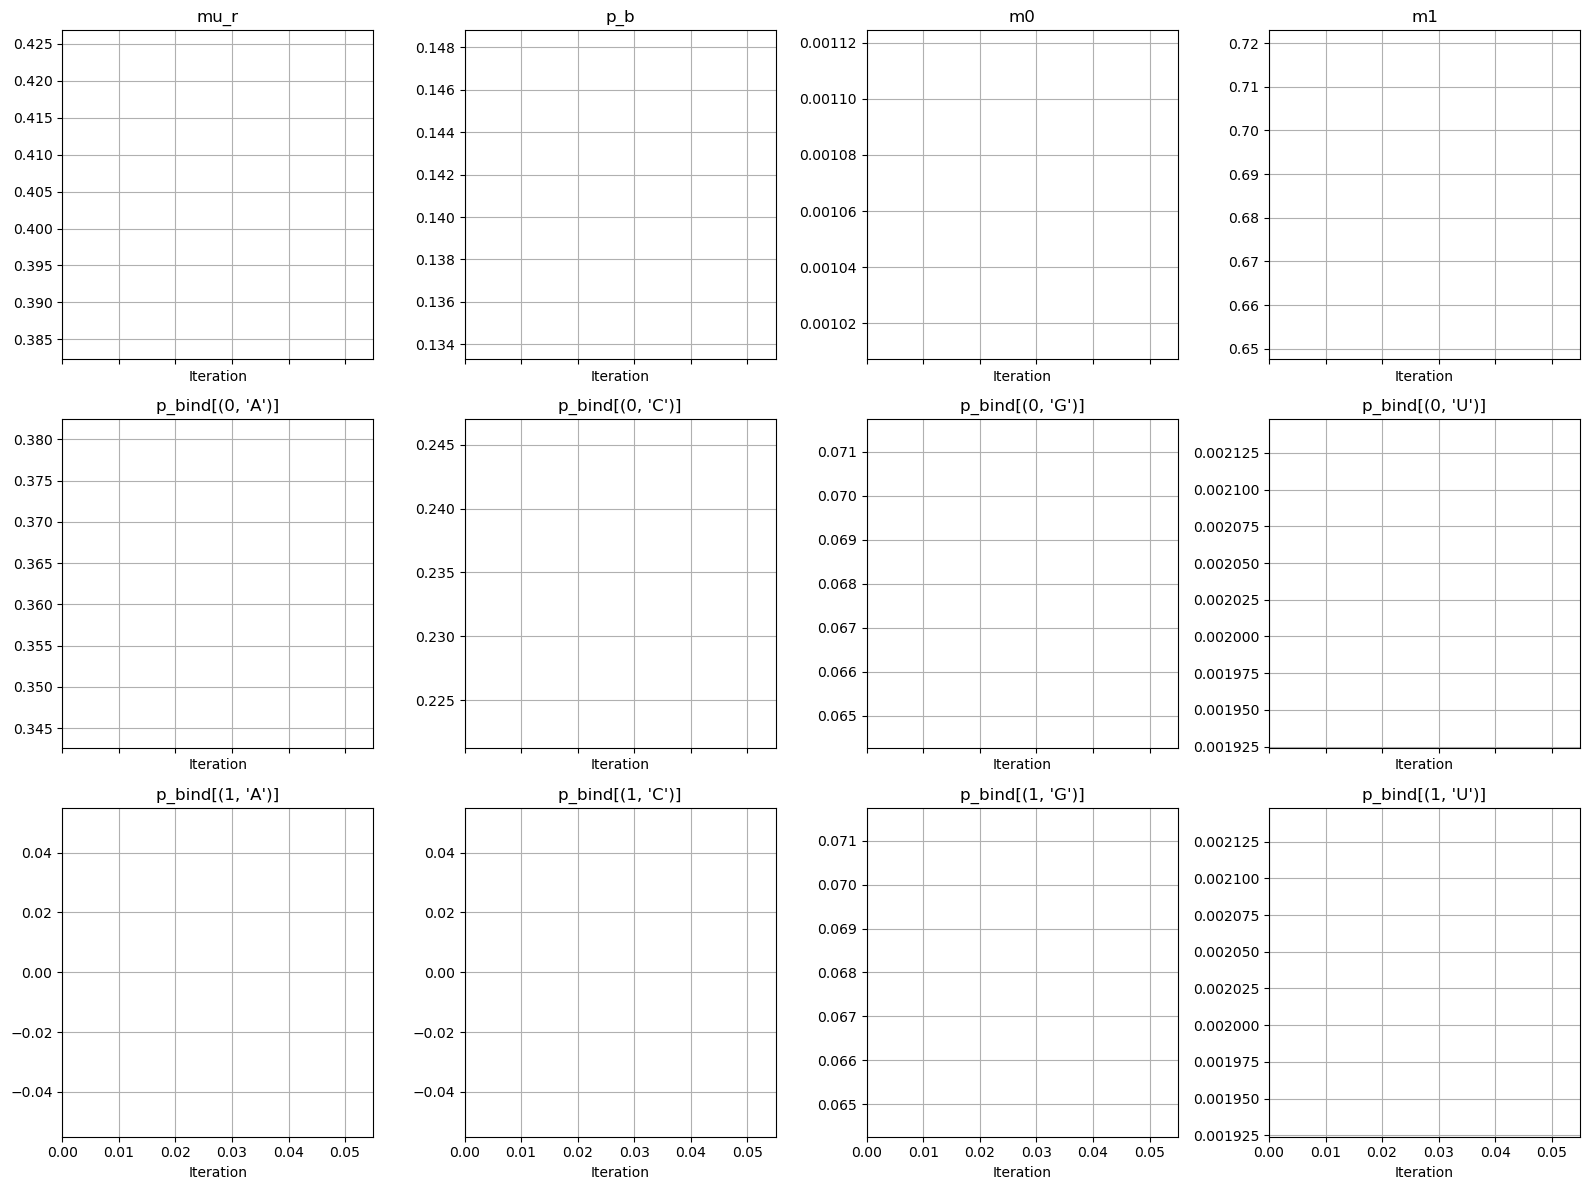

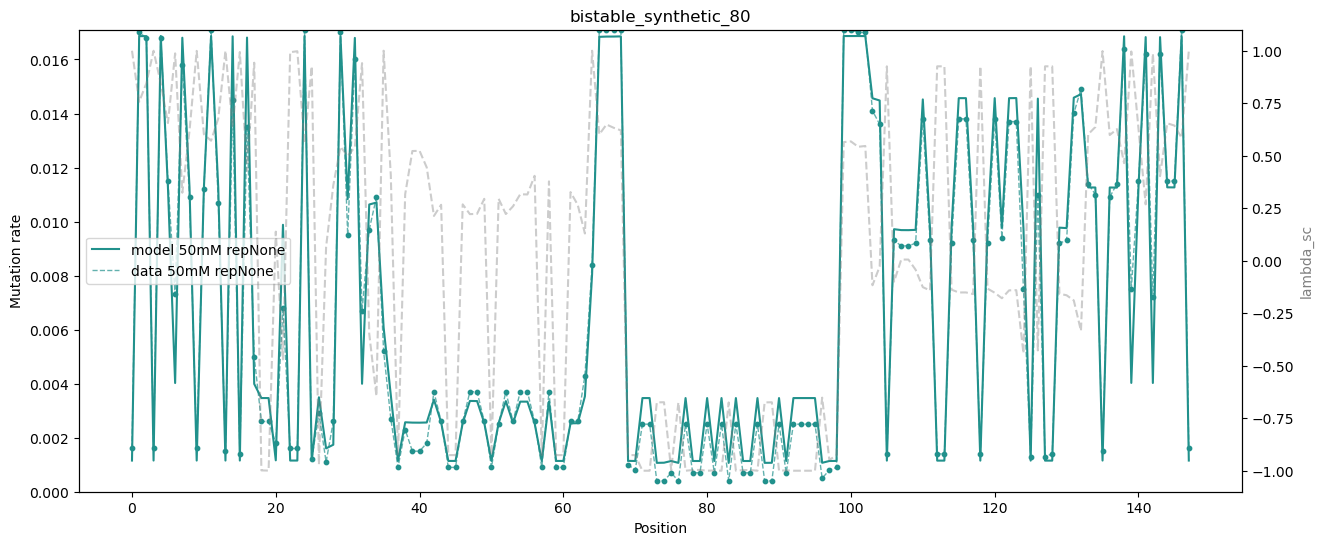

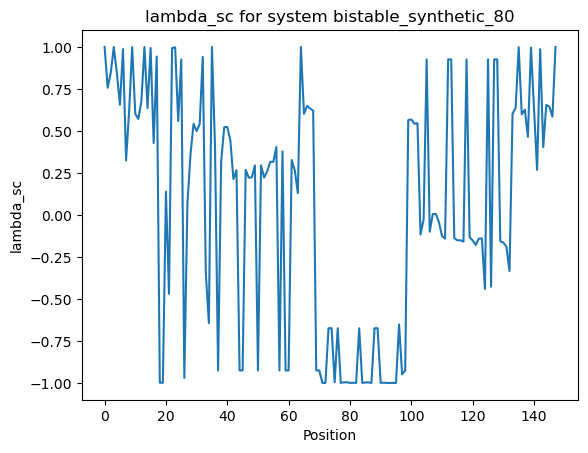

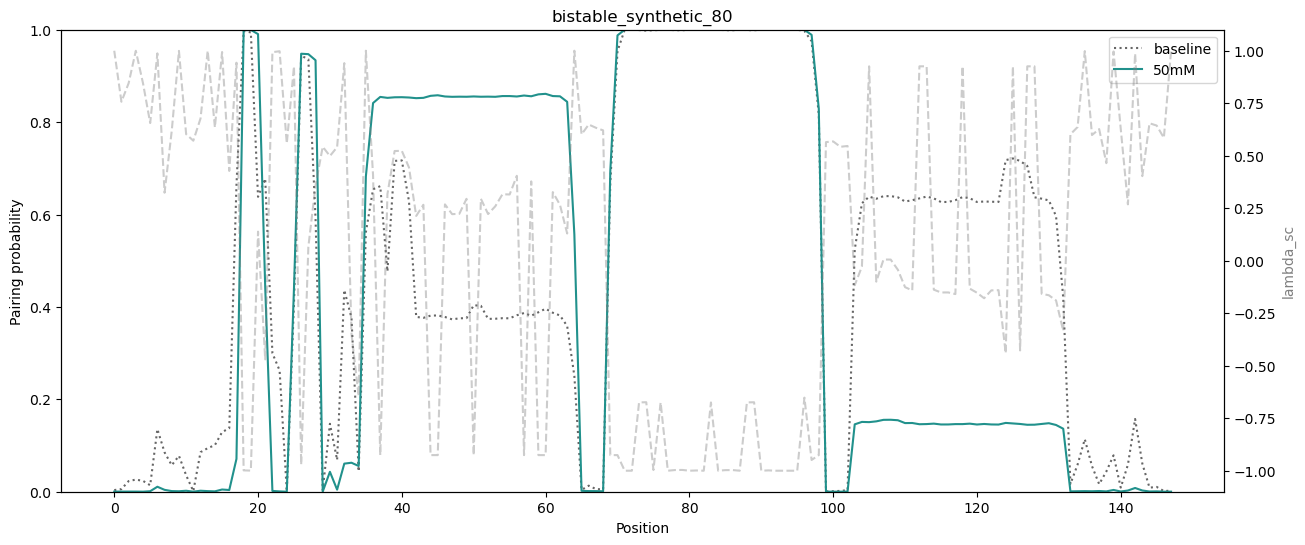

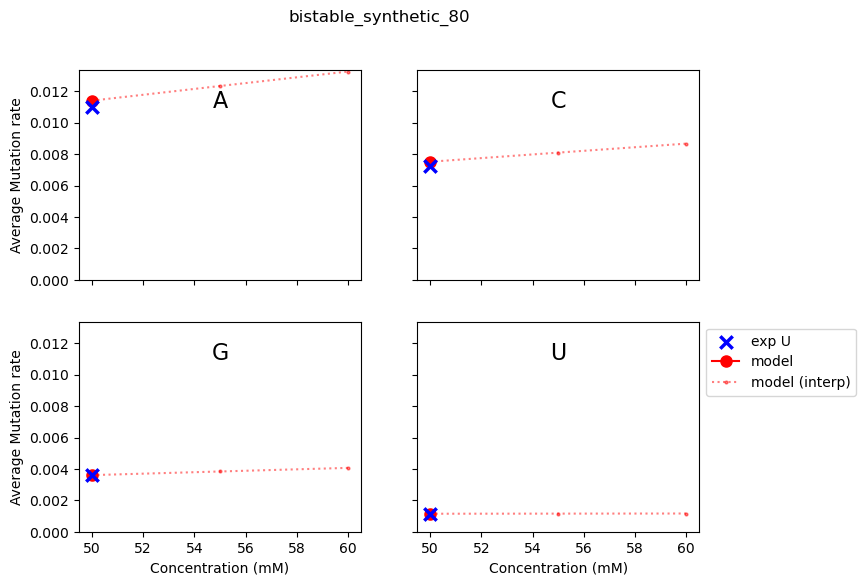

fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[INFO] Plots saved
fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[INFO] Fit result:
   message: ABNORMAL: 
  success: False
   status: 2
      fun: 543.8247889179897
        x: [ 4.046e-01  1.410e-01 ...  5.850e-01  9.999e-01]
      nit: 1
      jac: [ 0.000e+00  0.000e+00 ...  6.689e-03  1.177e-03]
     nfev: 45
     njev: 45
 hess_inv: <156x156 LbfgsInvHessProduct with dtype=float64>

Finished fitting process of bistable_synthetic_80, 2026-07-10 10:56:19.095501
fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[INFO] Finished fitting process of bistable_synthetic_80, 2026-07-10 10:56:19.095501
fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80

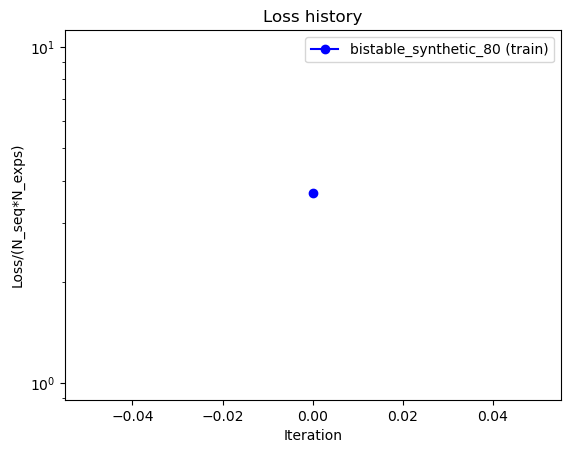

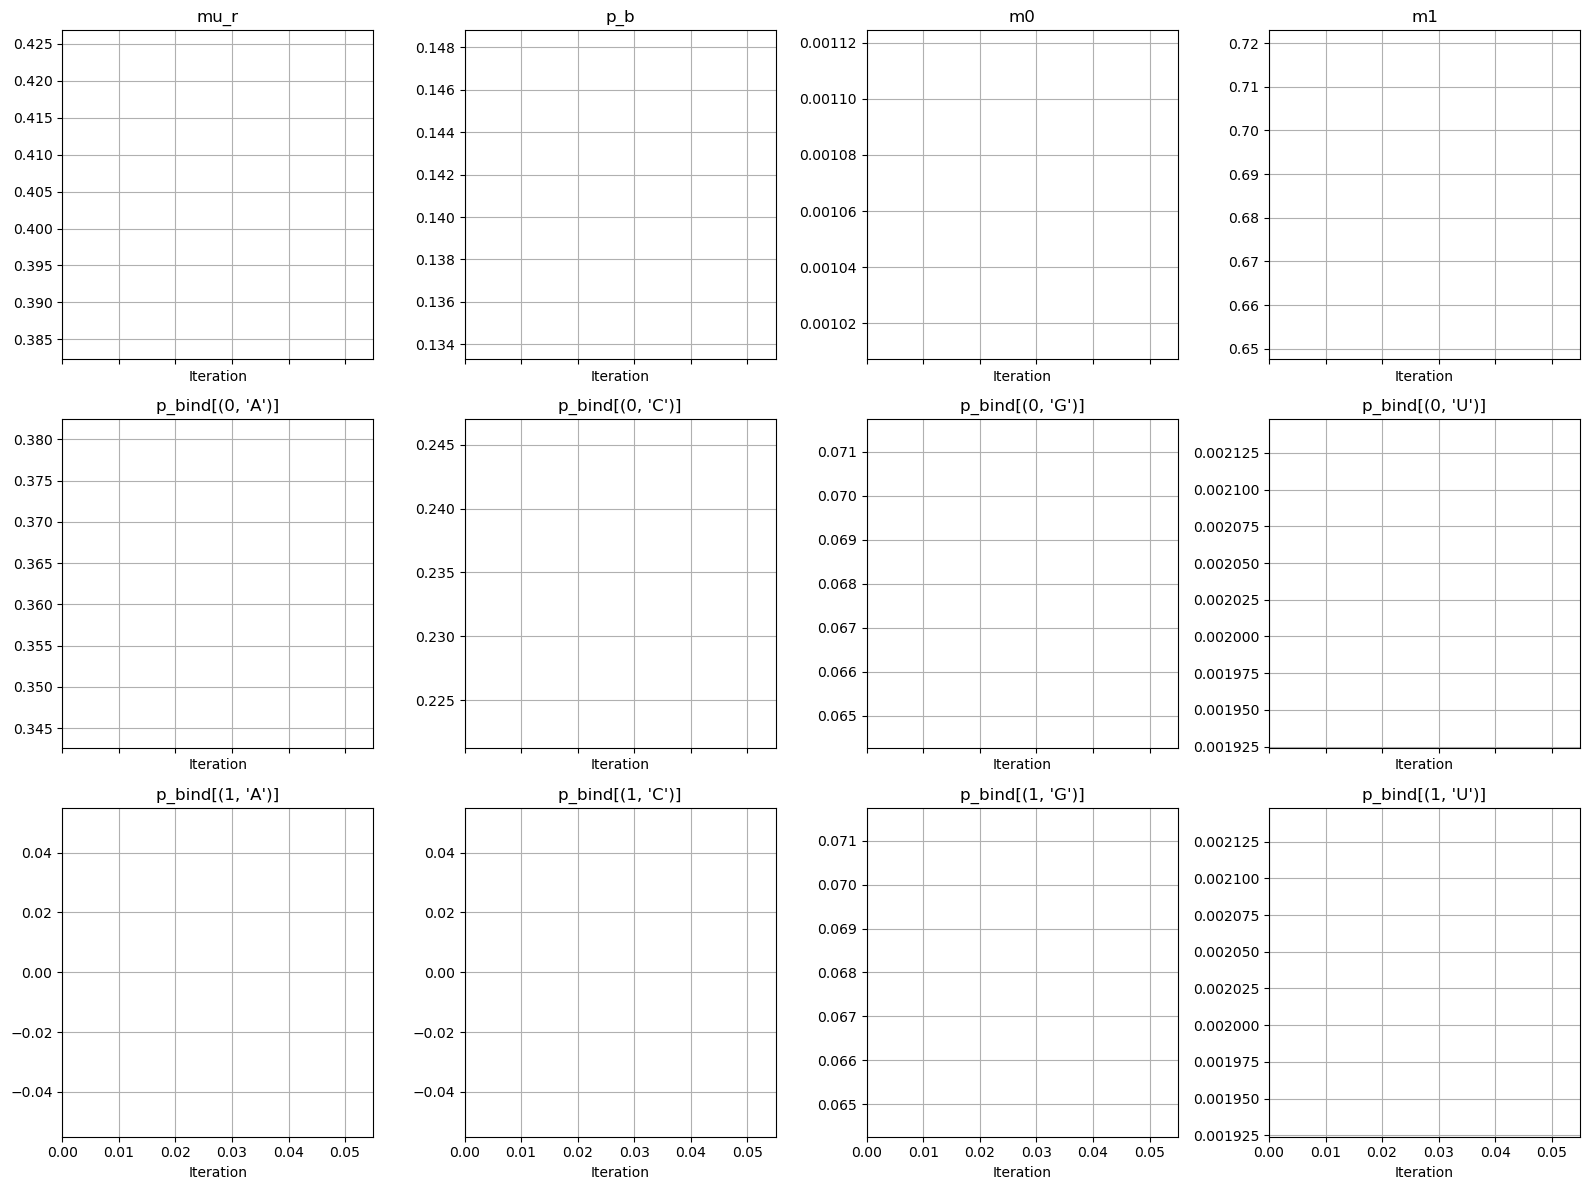

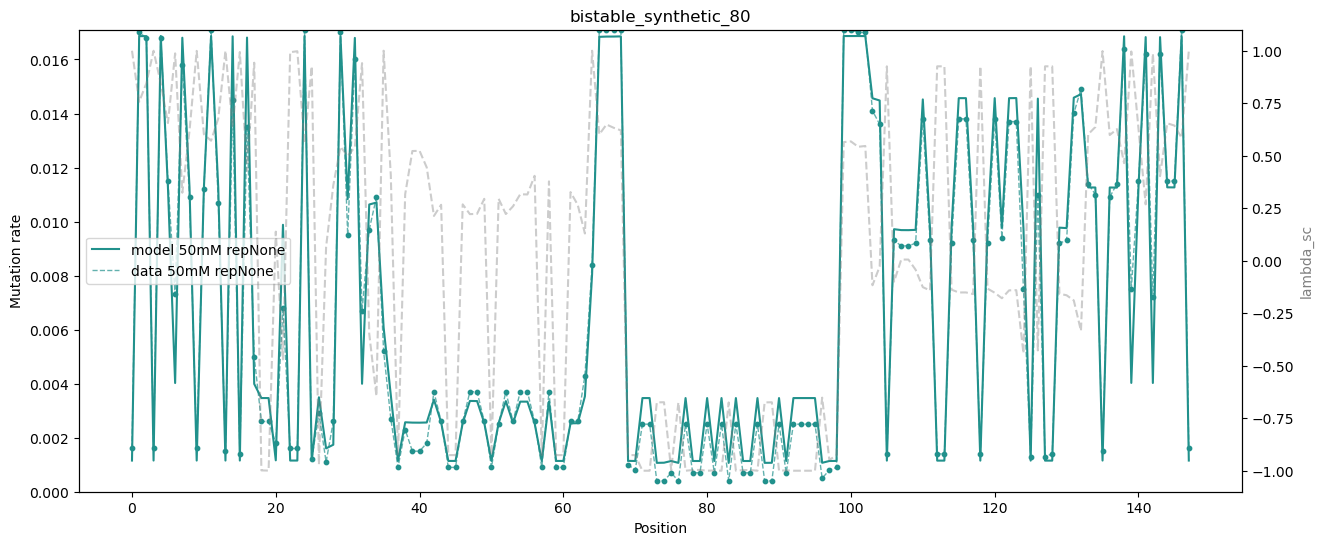

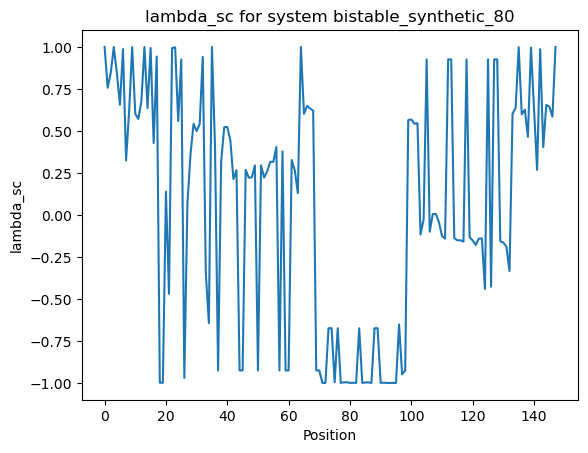

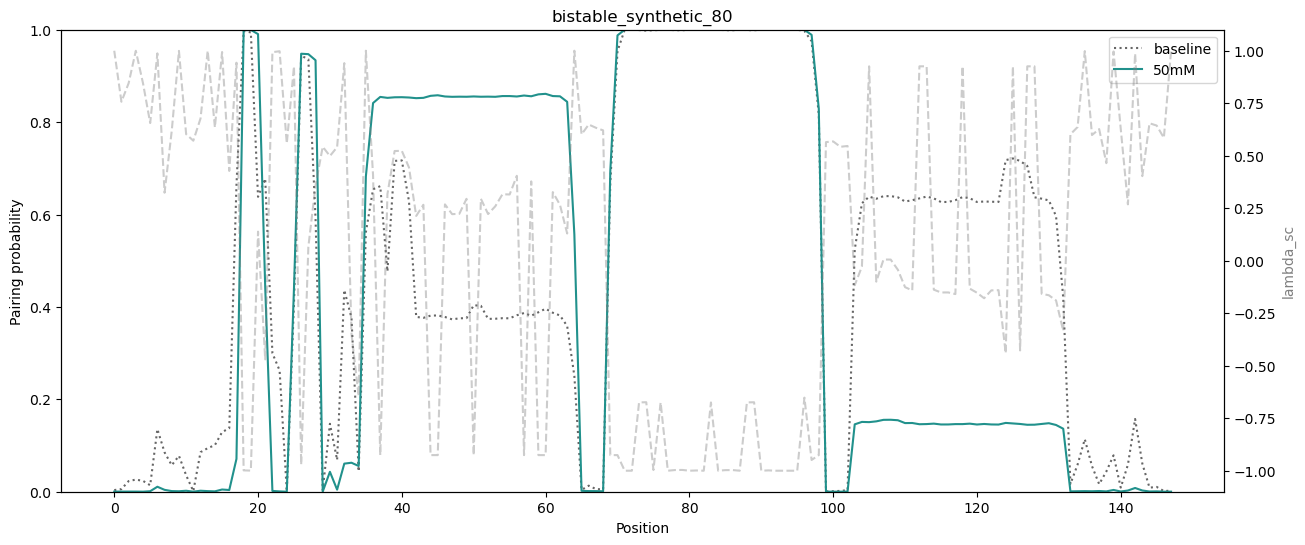

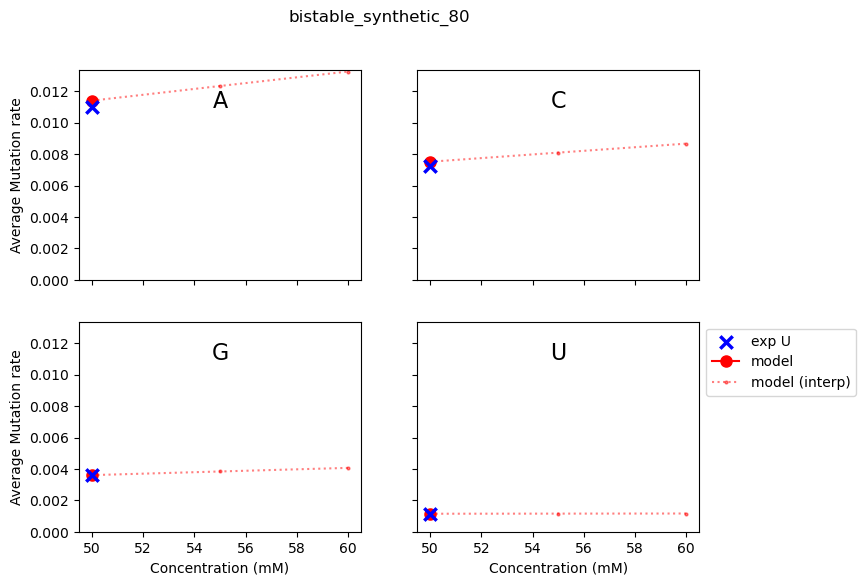

fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[INFO] Plots saved
fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[INFO] Fit metadata saved to fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/fit_metadata.json
fits_paper/designed_sequence/outputs/synthetic_bistable_notebook_init_guess/synthetic_bistable_80/detailed/synthetic_bistable_80.log[INFO] Execution finished in 0:02:58.892296

Converged: False  |  final loss: 543.8248  |  message: ABNORMAL: 


In [9]:
result_2 = multi_sys_init_guess.fit()
print(f"\nConverged: {result_2.success}  |  final loss: {result_2.fun:.4f}  |  message: {result_2.message}")